In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


In [11]:
# KNN implementation from scratch - for Binary Classification 

class KNNClassifier :
    def __init__(self , k=3):
        self.k = k

    def _euclidean_dist(self , x1 , x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def fit(self , X , y): # at fit time knn is just a Lazy learner 
        self.X_train = X
        self.y_train = y

    def _predict_one(self , x):
        distances = [self._euclidean_dist(x , x_train) for x_train in self.X_train] # distance calculation

        knn_indices = np.argsort(distances)[:self.k]  # sorting the distances and calculate the nearest k distance indices

        knn_classes = [self.y_train[i] for i in knn_indices] # calculating classes using indices 

        majority_class = np.argmax(np.bincount(knn_classes)) # calculating majority frequencies 
        return majority_class

    def predict(self , X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)

In [12]:
# data 

X_train = np.array([
    [1, 2] ,
    [2, 3] ,
    [3, 3] ,
    [6, 5] ,
    [7, 7] 
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

model = KNNClassifier()
model.fit(X_train , y_train)

y_pred = model.predict(X_test)
print("Y Predictions:" , y_pred)

Y Predictions: [0 1]


<Axes: xlabel='x1', ylabel='x2'>

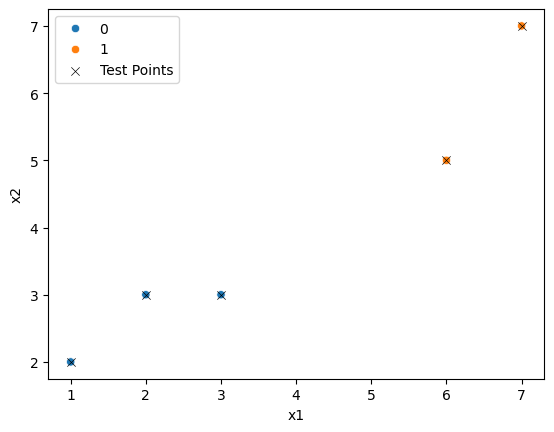

In [ ]:
# Visualiza 

X_train_df = pd.DataFrame(X_train , columns=["x1" , "x2"])
X_train_df["label"] = y_train

# X_train_df 
sns.scatterplot(
    data=X_train_df ,
    x = "x1",
    y = "x2",
    hue="label"
)


X_test_df = pd.DataFrame(X_test , columns=["x1" , "x2"])
sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    color="black",
    marker="x",
    label="Test Points"
)


<Axes: xlabel='x1', ylabel='x2'>

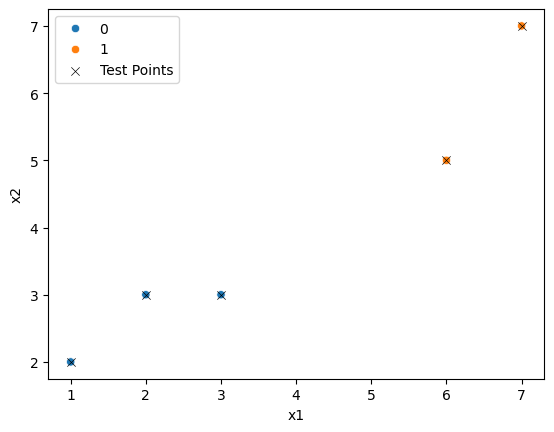